# 高速版：6種類の質問で創薬標的の可能性を採点する

ノートブック 02 の「時間がかかりすぎる」問題に対する実装です。次の4つのアイデアを入れています。

| # | アイデア | 実装 |
|---|---|---|
| 1 | サンプリングをやめる | 確率読みだけ。Yes の数は出さない |
| 2 | 順序入れ替えは最初の `N_CALIB` 遺伝子だけ | 両順で聞いて「順序の癖」を質問ごとに推定し、残りは1順で聞いて補正する |
| 4 | 共通の前置きを1回だけ処理する | llama.cpp の `save_state / load_state` で前置きの KV キャッシュを保存し、遺伝子ごとに復元。処理するのは遺伝子名と質問だけ |
| 5 | 1回の処理で6問に答えさせる | 質問を順に流し、各「Answer:」の位置で Yes/No の確率を読む。前の答えはモデル自身の答え（温度0）で条件付け |

さらに **回答の尤度**（`USE_PMI`）を任意で出します。「この遺伝子は {病名} の確立した標的である」という文の **病名部分の対数尤度** を、遺伝子を伏せた文の尤度と比べた差（PMI: pointwise mutual information）です。Yes/No を聞かず、文の自然さで測る別の物差しになります。

## 6種類の質問

| 群 | # | 質問 |
|---|---|---|
| A 直接の証拠 | A1 | 既存薬または臨床試験中の薬の標的か |
| | A2 | ヒト遺伝学の証拠（まれな変異による発症、一般集団の変異と発症リスク・重症度の関連）があるか |
| B しくみの証拠 | B1 | 記載した症状を起こす主要な病態経路の中で働くか |
| | B2 | 記載した細胞で、症状を起こす機能異常の**主要な担い手**か（単に発現しているだけなら No）。`B2_VARIANT` で3通りから選択 |
| | B3 | 抑制または活性化すると、記載した症状のいずれかが改善すると予想されるか |
| | B4 | 既知の標的や原因遺伝子と直接相互作用する、または同じ経路の上流・下流にあるか |

スコアは OR の合成 `1 − Π(1 − p_i)`。**リストA（既知の再現）は6問全部、リストB（新規候補）は B1〜B4 だけ**で計算します。

## 前提
- 本命は **`~/llm/models` の GGUF を llama-cpp-python で直接動かす**経路です（KV キャッシュの保存・復元が使えるのはこれだけ）。Ollama では前置きの再処理が避けられないため、質問ごとに1回ずつ呼ぶ遅い経路になります。
- モデルが無い環境ではモック（擬似乱数）で動きます。数値に意味はありません。
- 病気の情報は「症状 → 臓器・細胞・機能」で書き、分子名・原因遺伝子名は書きません（ノートブック 02 と同じルール）。

### このセルがすること：準備

In [1]:
import os, re, csv, math, glob, json, time, random, hashlib, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 60)
ROOT = os.path.abspath("..")
print("ready:", ROOT)

ready: /home/user/gene_disease_prediction02


## 設定

### このセルがすること：速度に関わる変数とモデルの選択を宣言する（病気と遺伝子リストは前のセルで選択済み）
- `N_CALIB`：順序入れ替えを両方行う遺伝子数（先頭から）。ここで質問ごとの「順序の癖」を推定します。
- `USE_PMI`：回答の尤度（病名の対数尤度の差）も出す（GGUF のみ。1遺伝子あたり数トークンの追加処理）。
- モデル：`~/llm/models` の GGUF（本命）か Ollama。`BACKEND` と `MODEL_SELECT` で選びます。

## 疾患の選択

### このセルがすること：`data/diseases.json` の登録疾患から1つ選び、病名・症状の箇条書き・遺伝子リストを読み込む
- `DISEASE_KEY` を変えるだけで切り替わります：`ra` / `scz` / `cystinuria` / `prostate_cancer` / `achondroplasia`。
- 箇条書きは「症状 → 臓器・細胞・機能」で書かれ、分子名・原因遺伝子名を含みません（テストで HGNC 記号との照合済み）。
- 遺伝子リストは `data/genes/<疾患>_set100.tsv`。RA 以外はダミーに SLC トランスポーターを多数含みます（シスチン尿症は原因遺伝子も SLC なので厳しい検証になります）。

In [2]:
DISEASE_KEY = "ra"                    # "ra" / "scz" / "cystinuria" / "prostate_cancer" / "achondroplasia"
GENE_SET = "set100"                   # "set100" / "set1000" / "known" / "candidates"

REGISTRY = json.load(open(os.path.join(ROOT, "data", "diseases.json"), encoding="utf-8"))
print("登録疾患:", {k: v["name"] for k, v in REGISTRY.items()})
D = REGISTRY[DISEASE_KEY]
DISEASE = D["name"]
DISEASE_INFO = D["info"][:5]
GENE_FILE = os.path.join(ROOT, "data", "genes", f"{D['gene_prefix']}_{GENE_SET}.tsv")
print("選択:", DISEASE, "| 遺伝子リスト:", os.path.basename(GENE_FILE))
for b in DISEASE_INFO: print("  -", b[:110] + ("…" if len(b) > 110 else ""))

登録疾患: {'ra': 'rheumatoid arthritis', 'scz': 'schizophrenia', 'cystinuria': 'cystinuria', 'prostate_cancer': 'prostate cancer', 'achondroplasia': 'achondroplasia'}
選択: rheumatoid arthritis | 遺伝子リスト: ra_set100.tsv
  - Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic…
  - Progressive joint deformity and loss of function: invasive growth of the synovial lining cells and excessive b…
  - The inflammation is sustained by the adaptive immune system: self-reactive T cells, antibody-producing B cells…
  - Fatigue, low-grade fever and anaemia: systemic effects of inflammatory mediators released by the activated imm…
  - Accelerated cardiovascular disease and interstitial lung disease: consequences of long-standing systemic infla…


In [3]:
MAX_GENES = None                                   # 試運転なら 10

N_CALIB = 20                                       # 順序入れ替えを両方行う遺伝子数（順序の癖の推定用）
USE_PMI = True                                     # 回答の尤度（病名の対数尤度の差）も出す（GGUF のみ）
STRICT_PROMPT = True                               # 「大半の遺伝子は標的ではない」の前置き
N_CTX = 2048

# --- モデルの選択 ---
BACKEND = "auto"                                   # "auto" / "gguf" / "ollama" / "mock"
MODEL_DIR = os.path.expanduser("~/llm/models")
OLLAMA_URL = "http://localhost:11434"
MODEL_SELECT = "auto"                              # "auto" / 一覧の番号 / 名前の一部
PREFER = ("txgemma", "medgemma", "gemma")
models = []
for h in sorted(glob.glob(os.path.join(MODEL_DIR, "**", "*.gguf"), recursive=True)):
    models.append({"kind": "gguf", "name": os.path.basename(h), "path": h, "size_gb": round(os.path.getsize(h) / 1e9, 2)})
try:
    with urllib.request.urlopen(OLLAMA_URL + "/api/tags", timeout=3) as r:
        for m in json.load(r).get("models", []):
            models.append({"kind": "ollama", "name": m["name"], "path": m["name"], "size_gb": round(m.get("size", 0) / 1e9, 2)})
except Exception:
    pass
chosen = None
if BACKEND != "mock":
    if isinstance(MODEL_SELECT, int):
        chosen = models[MODEL_SELECT]
    else:
        pool = [m for m in models if BACKEND == "auto" or m["kind"] == BACKEND]
        if MODEL_SELECT != "auto": pool = [m for m in pool if MODEL_SELECT.lower() in m["name"].lower()]
        ranked = sorted(pool, key=lambda m: (min([i for i, p in enumerate(PREFER) if p in m["name"].lower()] or [99]),
                                             0 if m["kind"] == "gguf" else 1, m["name"]))   # 高速版は GGUF を優先
        chosen = ranked[0] if ranked else None
USE_LLM = chosen is not None
BACKEND_USED = chosen["kind"] if chosen else "mock"
MODEL_PATH = chosen["path"] if chosen else None
print("使えるモデル:"); [print(f"  [{i}] {m['kind']:6s} {m['size_gb']:6.2f} GB  {m['name']}") for i, m in enumerate(models)]
print("選択:", f"{BACKEND_USED}: {MODEL_PATH}" if USE_LLM else "モック（擬似乱数。数値に意味なし）")
OUT_DIR = os.path.join(ROOT, "outputs"); os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, os.path.basename(GENE_FILE).replace(".tsv", "") + "_six.csv")

使えるモデル:
選択: モック（擬似乱数。数値に意味なし）


## 6種類の質問と、キャッシュが効くプロンプトの並び

### このセルがすること：質問を定義し、「前置き（全遺伝子で共通）」と「遺伝子ごとの部分」を分けて組み立てる
- 前置きには役割・厳しめの注意・病名・症状の箇条書き・答え方の指示まで入れます。**ここは1文字も変わらない**ので、1回処理して保存できます。
- 遺伝子ごとの部分は「Gene: 記号 (タンパク質名)」と、6問を順に並べた文です。各問の末尾が「Answer:」で、その位置の Yes/No 確率を読みます。
- 順序入れ替えは、前置きの指示文「Answer with Yes or No」/「Answer with No or Yes」で行います（前置きが2通り → 保存する状態も2通り）。
- **B2 の改善**：旧版「発現していて機能異常に関わるか」は random でも 0.40 と緩かったので、既定を `driver`（主要な担い手か。発現しているだけ・維持機能・傍観者なら No）に変えました。`necessary`（その遺伝子を止めると異常が大きく減るか）も選べます。3通りを同じ遺伝子セットで回して、質問ごとの AUC（known vs random）を比べてください。
- **STRICT_NOTE に「同じ遺伝子族というだけでは不十分」という注意を追加しました。** SLC トランスポーターのダミー（血糖・胆汁酸・イオンなど、症状と無関係な基質を運ぶもの）でも、「腎臓の輸送体の病気」という文脈だけで Yes と答える「ファミリーの後光効果（family halo）」が起きうるためです。次のセクションの評価で、同じファミリーのダミーと違うファミリーのダミーを分けて見られるようにしてあります。

In [4]:
QUESTIONS = [  # (id, 群, 質問文)  {disease} は病名に置き換わる
    ("A1", "A", "Is this gene the molecular target of an approved drug or of a drug in clinical trials for {disease}?"),
    ("A2", "A", "Do human genetic variants in this gene, rare or common, cause {disease} or alter its risk or severity?"),
    ("B1", "B", "Does this gene act within a principal pathogenic pathway that produces the symptoms listed above?"),
    ("B2", "B", None),   # 下の B2_VARIANTS から B2_VARIANT で選ぶ
    ("B3", "B", "Would inhibiting or activating this gene be expected to improve at least one of the symptoms listed above?"),
    ("B4", "B", "Does this gene directly interact with, or lie immediately upstream or downstream of, established targets or causal genes of {disease}?"),
]
# B2 の言い回し。旧版（"loose"）は「発現している」だけで Yes になりやすく、random でも 0.40 だった。
B2_VARIANTS = {
    "loose":  "Is this gene expressed and active in the affected organs or cell types listed above, and involved in their abnormal function?",
    "driver": "In the affected cell types listed above, is this gene a principal driver of the abnormal function that produces the symptoms? "
              "Answer No if the gene is merely expressed there or has only a housekeeping or bystander role.",
    "necessary": "Is the abnormal function of the affected cell types listed above dependent on this gene, such that removing or blocking the gene in those cells "
                 "would substantially reduce the abnormality? Answer No for genes that are expressed there but not required.",
}
B2_VARIANT = "driver"                  # "loose" / "driver" / "necessary"
QUESTIONS = [(i, g, (B2_VARIANTS[B2_VARIANT] if i == "B2" else q)) for i, g, q in QUESTIONS]
QIDS = [q[0] for q in QUESTIONS]
print("B2 =", B2_VARIANT, ":", B2_VARIANTS[B2_VARIANT][:100] + "…")
STRICT_NOTE = ("Note: the vast majority of human genes are NOT drug targets for any given disease. "
               "Answer Yes only when there is clear evidence or a clear mechanistic link; otherwise answer No. "
               "Membership in the same gene family, superfamily or protein class as a true disease gene (e.g. being "
               "another member of the same transporter, channel, receptor or enzyme family) is NOT sufficient evidence "
               "by itself. Judge each gene on whether ITS OWN specific substrate, ligand, cargo or interaction partner "
               "matches the mechanism described above, not on family resemblance alone.\n")

def prefix_text(order="yes_first"):
    """全遺伝子で共通の前置き。order で答え方の指示だけが変わる。"""
    info = "\n".join(f"- {b}" for b in DISEASE_INFO)
    options = "Answer each question with Yes or No." if order == "yes_first" else "Answer each question with No or Yes."
    return ("You are an expert in drug discovery and human disease biology.\n" + (STRICT_NOTE if STRICT_PROMPT else "") +
            f"Disease: {DISEASE}\nTarget symptoms and the organ, cell and functional abnormalities behind them:\n{info}\n"
            f"{options}\n\n")

def gene_block(gene_label):
    return f"Gene: {gene_label}\n"

def question_line(qid):
    text = next(q for i, _, q in QUESTIONS if i == qid).format(disease=DISEASE)
    return f"{qid}. {text} Answer:"

print(prefix_text()); print(gene_block("TNF (tumor necrosis factor)") + question_line("A1") + " Yes\n" + question_line("A2") + " ...")

B2 = driver : In the affected cell types listed above, is this gene a principal driver of the abnormal function th…
You are an expert in drug discovery and human disease biology.
Note: the vast majority of human genes are NOT drug targets for any given disease. Answer Yes only when there is clear evidence or a clear mechanistic link; otherwise answer No. Membership in the same gene family, superfamily or protein class as a true disease gene (e.g. being another member of the same transporter, channel, receptor or enzyme family) is NOT sufficient evidence by itself. Judge each gene on whether ITS OWN specific substrate, ligand, cargo or interaction partner matches the mechanism described above, not on family resemblance alone.
Disease: rheumatoid arthritis
Target symptoms and the organ, cell and functional abnormalities behind them:
- Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic inflammation of the synovial membrane that l

## 入力遺伝子

### このセルがすること：遺伝子リストを読み、プロンプトに入れる名前（記号＋タンパク質名）を作る
- タンパク質名は、ファイルの `protein_name_uniprot` → HGNC の `gene_name` → 記号のみ、の順で使います（UniProt の照会はノートブック 02 参照）。

In [5]:
genes = pd.read_csv(GENE_FILE, sep="\t", dtype=str).fillna("")
for col in ("protein_name_uniprot", "gene_name", "category", "label"):
    if col not in genes.columns: genes[col] = ""
if MAX_GENES: genes = genes.head(MAX_GENES).copy()
genes["gene_label"] = [f"{g['symbol']} ({(g['protein_name_uniprot'] or g['gene_name']).split('|')[0]})" if (g["protein_name_uniprot"] or g["gene_name"]) else g["symbol"] for _, g in genes.iterrows()]
print(len(genes), "genes"); genes[["symbol", "gene_label", "category"]].head(5)

100 genes


,symbol,gene_label,category
0,PADI4,PADI4 (peptidyl arginine deiminase 4),candidate
1,CCL21,CCL21 (C-C motif chemokine ligand 21),candidate
2,TNFRSF14,TNFRSF14 (TNF receptor superfamily member 14),candidate
3,IL7R,IL7R (interleukin 7 receptor),candidate
4,IRF5,IRF5 (interferon regulatory factor 5),candidate


## 高速エンジン（GGUF を llama-cpp-python で直接動かす）

### `last_logprobs()` — 直前に処理した位置の対数確率（全語彙）
どんな def か：llama.cpp のコンテキストから最後の位置の logits を読み、log-softmax にして返します。`llm.scores` は使いません（llama-cpp-python 0.3 系は `logits_all=False` だと `scores` を埋めないため）。
return：numpy 配列（語彙数）。

### `option_logprob(lp, ids)` — 綴り違いを合算した対数確率
どんな def か：「Yes」「 Yes」「yes」… の各トークン id の対数確率を合算（log-sum-exp）します。完全一致を優先すると末端の綴りを拾って逆転するため（ノートブック 02 で実機確認）。
return：float。

### `score_gene(gene_label, order)` — 1遺伝子・6問を1回の処理で採点する
各ステップ：
1. 保存しておいた前置きの状態（`order` に応じて2通り）を `load_state` で復元する。前置きは再処理しない。
2. 遺伝子ブロックを処理する。
3. 質問1の文を処理し、「Answer:」の位置で Yes/No の確率を読む。
4. モデル自身の答え（温度0：確率の高い方）のトークンと改行を処理して、質問2へ進む（guidance の `select` と同じ条件付け）。
5. 6問分くり返す。
return：dict（質問 id → p_yes）と、モデルの答えの並び（例 `YNYYNN`）。

### `sequence_logprob(prefix, continuation)` — 回答の尤度（強制デコード）
どんな def か：`prefix` の後に `continuation` が続く対数確率を、トークンを1つずつ強制しながら足し合わせて返します。`USE_PMI` では「{gene} is an established therapeutic target for the disease:」に続く病名の尤度から、遺伝子を伏せた文の尤度を引いた差（PMI）を出します。
return：float（対数尤度）。

### このセルがすること：エンジンを読み込み、前置きを2通り処理して状態を保存し、上の def を定義する

In [6]:
YES_SPELL, NO_SPELL = ["Yes", " Yes", "yes", " yes", "YES", " YES"], ["No", " No", "no", " no", "NO", " NO"]
prefix_state = {}

if BACKEND_USED == "gguf":
    from llama_cpp import Llama
    llm = Llama(model_path=MODEL_PATH, n_ctx=N_CTX, n_gpu_layers=-1, logits_all=False, verbose=False)
    def tok(text, bos=False): return llm.tokenize(text.encode("utf-8"), add_bos=bos, special=bos)
    def ids_of(spellings):
        out = []
        for s in spellings:
            t = tok(s)
            if len(t) == 1 and t[0] not in out: out.append(t[0])
        return out
    YES_IDS, NO_IDS = ids_of(YES_SPELL), ids_of(NO_SPELL)
    NL = tok("\n")
    for order in ("yes_first", "no_first"):                        # 前置きを2通り処理して保存（1回きり）
        llm.reset(); llm.eval(tok(prefix_text(order), bos=True))
        prefix_state[order] = (llm.save_state(), llm.n_tokens)
    print(f"GGUF engine ready | prefix tokens: {prefix_state['yes_first'][1]} | yes ids {YES_IDS} | no ids {NO_IDS}")
elif BACKEND_USED == "ollama":
    print("Ollama を使います（前置きのキャッシュ保存はできないため、質問ごとに1回ずつ呼ぶ遅い経路です）:", MODEL_PATH)
else:
    print("警告: モデルが無いのでモック（擬似乱数）です。")

def last_logprobs():
    lg = np.ctypeslib.as_array(llm._ctx.get_logits(), shape=(llm.n_vocab(),)).astype(np.float64)
    lg = lg - lg.max()
    return lg - math.log(np.exp(lg).sum())

def option_logprob(lp, ids):
    v = [lp[i] for i in ids]; m = max(v)
    return m + math.log(sum(math.exp(x - m) for x in v))

def score_gene_gguf(gene_label, order="yes_first"):
    st, n = prefix_state[order]
    llm.load_state(st)                                              # 1. 前置きの状態を復元
    llm.eval(tok(gene_block(gene_label)))                           # 2. 遺伝子ブロック
    out, chain = {}, ""
    for qid in QIDS:
        llm.eval(tok(question_line(qid)))                           # 3. 質問文 → 「Answer:」の位置
        lp = last_logprobs()
        ly, ln = option_logprob(lp, YES_IDS), option_logprob(lp, NO_IDS)
        out[qid] = math.exp(ly) / (math.exp(ly) + math.exp(ln))
        forced = YES_IDS[0] if ly >= ln else NO_IDS[0]              # 4. モデル自身の答えで条件付け
        chain += "Y" if ly >= ln else "N"
        llm.eval([forced] + NL)
    return out, chain

def sequence_logprob(prefix, continuation):
    llm.reset(); llm.eval(tok(prefix, bos=True))
    total = 0.0
    for t in tok(continuation):
        total += float(last_logprobs()[t]); llm.eval([t])
    return total

# ---- Ollama（遅い経路）: 質問ごとに raw テンプレートで1回ずつ ----
def ollama_yes_prob(prompt_body):
    n = str(MODEL_PATH).lower()
    if "gemma" in n:        tpl = "<start_of_turn>user\n{body}<end_of_turn>\n<start_of_turn>model\nAnswer:"
    elif "qwen3" in n:      tpl = "<|im_start|>user\n{body}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nAnswer:"   # 思考ブロックを空にして答えの位置に来させる
    elif "qwen" in n or "deepseek" in n: tpl = "<|im_start|>user\n{body}<|im_end|>\n<|im_start|>assistant\nAnswer:"
    elif "mistral" in n:    tpl = "[INST] {body} [/INST] Answer:"
    elif "llama" in n:      tpl = "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n{body}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nAnswer:"
    else:                   tpl = "{body}\nAnswer:"
    body = json.dumps({"model": MODEL_PATH, "prompt": tpl.format(body=prompt_body), "raw": True, "stream": False,
                       "logprobs": True, "top_logprobs": 20, "options": {"temperature": 0, "num_predict": 1}}).encode()
    req = urllib.request.Request(OLLAMA_URL + "/api/generate", data=body, headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=300) as r:
        lps = json.load(r).get("logprobs") or []
    top = {t["token"]: t["logprob"] for t in (lps[0].get("top_logprobs", []) if lps else [])}
    def lse(vals): m = max(vals); return m + math.log(sum(math.exp(v - m) for v in vals))
    y = [v for t, v in top.items() if t.strip().lower() == "yes"]; n = [v for t, v in top.items() if t.strip().lower() == "no"]
    floor = min(top.values()) if top else -20
    ly, ln = (lse(y) if y else floor), (lse(n) if n else floor)
    return math.exp(ly) / (math.exp(ly) + math.exp(ln))

def score_gene_ollama(gene_label, order="yes_first"):
    out, chain = {}, ""
    for qid in QIDS:
        body = prefix_text(order) + gene_block(gene_label) + question_line(qid).replace(" Answer:", "")
        out[qid] = ollama_yes_prob(body); chain += "Y" if out[qid] >= 0.5 else "N"
    return out, chain

def score_gene_mock(gene_label, order="yes_first"):
    out = {}
    for qid in QIDS:
        h = int(hashlib.md5((gene_label + qid + order).encode()).hexdigest(), 16) % 1000 / 1000
        out[qid] = h
    return out, "".join("Y" if out[q] >= 0.5 else "N" for q in QIDS)

score_gene = {"gguf": score_gene_gguf, "ollama": score_gene_ollama}.get(BACKEND_USED, score_gene_mock)
t0 = time.time(); demo, chain = score_gene("TNF (tumor necrosis factor)"); dt = time.time() - t0
print("test TNF:", {k: round(v, 3) for k, v in demo.items()}, chain, f"| {dt:.2f}s for 6 questions")

警告: モデルが無いのでモック（擬似乱数）です。
test TNF: {'A1': 0.42, 'A2': 0.629, 'B1': 0.91, 'B2': 0.401, 'B3': 0.214, 'B4': 0.398} NYYNNN | 0.00s for 6 questions


## 順序の癖の推定（アイデア2）

### このセルがすること：先頭 `N_CALIB` 遺伝子だけ両順で聞き、質問ごとの差 δ = mean(p_yes_first − p_no_first) を求める
- 残りの遺伝子は yes_first だけ聞き、`p − δ/2` で補正します（両順の平均に相当）。
- δ の大きさが 0.1 を超える質問は、並び順に敏感な聞き方だという警告でもあります。

In [7]:
calib_rows, delta = [], {q: 0.0 for q in QIDS}
n_calib = min(N_CALIB, len(genes))
t0 = time.time()
for _, g in genes.head(n_calib).iterrows():
    p1, _ = score_gene(g["gene_label"], "yes_first"); p2, _ = score_gene(g["gene_label"], "no_first")
    calib_rows.append({"symbol": g["symbol"], **{f"{q}_yf": p1[q] for q in QIDS}, **{f"{q}_nf": p2[q] for q in QIDS}})
cal = pd.DataFrame(calib_rows)
for q in QIDS:
    delta[q] = float((cal[f"{q}_yf"] - cal[f"{q}_nf"]).mean())
print(f"{n_calib} 遺伝子 × 2順 × 6問: {time.time()-t0:.1f}s")
print("順序の癖 δ（yes_first − no_first の平均）:", {q: round(v, 3) for q, v in delta.items()})
for q, v in delta.items():
    if abs(v) > 0.1: print(f"  [注意] {q} は並び順に敏感です（δ={v:+.2f}）")

20 遺伝子 × 2順 × 6問: 0.0s
順序の癖 δ（yes_first − no_first の平均）: {'A1': -0.094, 'A2': 0.018, 'B1': -0.129, 'B2': -0.056, 'B3': -0.143, 'B4': 0.071}
  [注意] B1 は並び順に敏感です（δ=-0.13）
  [注意] B3 は並び順に敏感です（δ=-0.14）


## 実行（1遺伝子 = 1回の処理）

### このセルがすること：全遺伝子を採点し、合成スコアと（任意で）尤度を CSV に書く
- `p_A1 … p_B4`：順序補正後の「はい」確率。`chain`：モデル自身の答えの並び（例 `YYNYNN`）。
- `score_all` / `score_B`：OR 合成 `1 − Π(1 − p)`（6問 / B1〜B4）。**各問が 0.9 以上だと 1.000 に飽和して同点になる**ので、順位には `logit_mean_all` / `logit_mean_B`（対数オッズの平均。飽和せず、強さが足し合わさる）を勧めます。`mean_p_*` は確率の平均、`max_B` は B の最大値。
- `pmi`：回答の尤度。log P(病名 | 「{gene} is an established therapeutic target for the disease:」) − log P(病名 | 遺伝子を伏せた同じ文)。正なら、その遺伝子と病名の結び付きが平均より強い。

In [8]:
rows, t0 = [], time.time()
pmi_base = None
if USE_PMI and BACKEND_USED == "gguf":
    pmi_base = sequence_logprob("This gene is an established therapeutic target for the disease:", " " + DISEASE)
for i, g in genes.iterrows():
    if i < n_calib:
        p = {q: (cal.loc[i, f"{q}_yf"] + cal.loc[i, f"{q}_nf"]) / 2 for q in QIDS}; chain = ""
    else:
        p_raw, chain = score_gene(g["gene_label"], "yes_first")
        p = {q: min(1.0, max(0.0, p_raw[q] - delta[q] / 2)) for q in QIDS}
    score_all = 1 - np.prod([1 - p[q] for q in QIDS])
    b = [p[q] for q in QIDS if q.startswith("B")]
    logit = lambda x: math.log(max(x, 1e-6) / max(1 - x, 1e-6))          # 対数オッズ（飽和しない合成用）
    pmi = ""
    if pmi_base is not None:
        pmi = sequence_logprob(f"{g['gene_label']} is an established therapeutic target for the disease:", " " + DISEASE) - pmi_base
    rows.append({"symbol": g["symbol"], "gene_label": g["gene_label"], "category": g["category"], "label": g["label"],
                 **{f"p_{q}": round(p[q], 4) for q in QIDS}, "chain": chain, "score_all": round(score_all, 4),
                 "score_B": round(1 - np.prod([1 - x for x in b]), 4), "max_B": round(max(b), 4),
                 "logit_mean_all": round(float(np.mean([logit(p[q]) for q in QIDS])), 3), "logit_mean_B": round(float(np.mean([logit(x) for x in b])), 3),
                 "mean_p_all": round(float(np.mean([p[q] for q in QIDS])), 4), "mean_p_B": round(float(np.mean(b)), 4),
                 "pmi": "" if pmi == "" else round(pmi, 3),
                 "model": f"{BACKEND_USED}:{os.path.basename(str(MODEL_PATH))}" if USE_LLM else "MOCK", "disease": DISEASE})
    if (i + 1) % 10 == 0 or i + 1 == len(genes):
        print(f"{i+1:4d}/{len(genes)} {g['symbol']:10s} {g['category']:9s} OR_B={rows[-1]['score_B']:.3f} logitB={rows[-1]['logit_mean_B']:+.2f} {chain} pmi={rows[-1]['pmi']}  ({time.time()-t0:.0f}s)")
res = pd.DataFrame(rows); res.to_csv(OUT_CSV, index=False)
print(f"elapsed {time.time()-t0:.0f}s for {len(genes)} genes → {(time.time()-t0)/len(genes):.2f}s/gene | wrote {OUT_CSV}")

  10/100 IKBKB      candidate OR_B=0.924 logitB=-0.11  pmi=  (0s)
  20/100 IL23A      candidate OR_B=0.982 logitB=+0.43  pmi=  (0s)
  30/100 IL17A      candidate OR_B=1.000 logitB=+2.85 NNNNYN pmi=  (0s)
  40/100 IL10       candidate OR_B=1.000 logitB=+3.21 YNYNNY pmi=  (0s)
  50/100 DHFR       known     OR_B=0.987 logitB=-0.16 NNYYNN pmi=  (0s)
  60/100 BLK        candidate OR_B=0.904 logitB=-0.40 YNNYYN pmi=  (0s)
  70/100 AFF3       candidate OR_B=0.927 logitB=-0.32 NNYNYN pmi=  (0s)
  80/100 IL2RA      candidate OR_B=0.989 logitB=+0.54 NYNYYN pmi=  (0s)
  90/100 CSF2RB     candidate OR_B=0.511 logitB=-2.13 NNNNNN pmi=  (0s)
 100/100 POLGARF    random    OR_B=0.998 logitB=+1.12 NNYYNY pmi=  (0s)
elapsed 0s for 100 genes → 0.00s/gene | wrote /home/user/gene_disease_prediction02/outputs/ra_set100_six.csv


## 評価

### このセルがすること：スコアごとの AUC と分類別の分布を出す
- **ファミリーの後光効果チェック**：ダミー遺伝子を「正解と同じ遺伝子ファミリー」と「違うファミリー」に分け、それぞれで known との AUC を比べます。同じファミリーだけ AUC が低ければ、質問が基質・機構ではなく記号の見た目（SLC という名前）に釣られている疑いがあります。
- `score_all`（6問）は既知の再現、`score_B`（B のみ）は「直接の証拠なしで既知を上に置けるか」の検証です。
- 質問ごとの AUC で、どの質問が効いているかが分かります。効かない質問は外して問数を減らせます。

警告: モックの数値です。


,p_A1,p_A2,p_B1,p_B2,p_B3,p_B4,score_all,score_B,max_B,logit_mean_all,logit_mean_B,mean_p_all,mean_p_B
category,,,,,,,,,,,,,
candidate,0.516,0.481,0.571,0.529,0.510,0.522,0.986,0.953,0.817,0.391,0.633,0.522,0.533
known,0.451,0.432,0.494,0.560,0.571,0.317,0.981,0.907,0.776,0.207,0.514,0.471,0.486
random,0.601,0.471,0.420,0.453,0.576,0.564,0.992,0.944,0.838,0.271,0.329,0.514,0.503


,AUC known vs others,AUC known vs random,AUC candidate vs random
p_A1,0.413,0.314,0.414
p_A2,0.448,0.431,0.515
p_B1,0.449,0.581,0.657
p_B2,0.543,0.581,0.579
p_B3,0.542,0.476,0.444
p_B4,0.280,0.231,0.462
score_all,0.401,0.398,0.521
score_B,0.460,0.481,0.535
max_B,0.460,0.424,0.469
logit_mean_all,0.402,0.419,0.533


ダミーの内訳: 正解と同じファミリー 0 件 / 違うファミリー 14 件（ファミリー = 記号の文字+数字部分。例 SLC7A9 → SLC7）
同じ/違うファミリーのダミーがどちらも少なく（3件未満）、この比較は統計的に頼りません。
同点（小数3桁）の遺伝子数: {'score_all': 77, 'score_B': 63, 'logit_mean_B': 2} ← OR 合成は 1.000 に飽和して同点が増える。順位には logit_mean を勧める


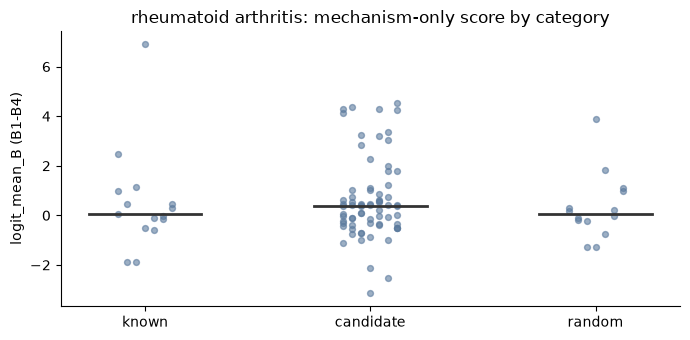

,symbol,category,logit_mean_all,logit_mean_B,score_B,pmi,chain,p_A1,p_A2,p_B1,p_B2,p_B3,p_B4
86,MS4A1,known,5.074,6.920,1.0,,YYNYYY,0.8461,0.7430,0.1373,1.0000,1.0000,0.8685
53,STAT4,candidate,3.575,4.537,1.0,,YYYYNY,0.5611,0.9550,1.0000,0.8602,0.3254,0.9625
55,CD247,candidate,2.740,4.374,1.0,,NYYYYY,0.2621,0.4940,1.0000,0.5382,0.9554,0.6145
51,IL1B,candidate,2.411,4.296,1.0,,NNYYYN,0.1961,0.2130,1.0000,0.7062,0.9344,0.4594
25,TNFRSF9,candidate,3.534,4.293,1.0,,YYYYYY,0.8801,0.8851,0.8153,1.0000,0.7584,0.6744
83,ARID5B,candidate,3.208,4.252,1.0,,YYYYYN,0.8621,0.6000,0.9473,0.7542,1.0000,0.3065
35,IL17RA,candidate,2.335,4.146,1.0,,NNYYYY,0.4561,0.0830,1.0000,0.5682,0.9013,0.5705
42,GGTLC3,random,3.185,3.879,1.0,,YYNNYY,0.8771,0.8360,0.3883,0.2722,1.0000,0.9585
60,MAPK14,candidate,1.795,3.378,1.0,,YNYNNY,0.5561,0.0490,1.0000,0.4992,0.3374,0.5925
88,CXCR5,candidate,1.562,3.235,1.0,,NNYNNY,0.0681,0.2780,1.0000,0.3932,0.2703,0.6345


In [9]:
def auc(pos, neg):
    pos, neg = list(pos), list(neg)
    if not pos or not neg: return float("nan")
    return sum(1.0 if a > b else 0.5 if a == b else 0.0 for a in pos for b in neg) / (len(pos) * len(neg))
if not USE_LLM: print("警告: モックの数値です。")
score_cols = [f"p_{q}" for q in QIDS] + ["score_all", "score_B", "max_B", "logit_mean_all", "logit_mean_B", "mean_p_all", "mean_p_B"] + (["pmi"] if res["pmi"].astype(str).str.len().gt(0).any() else [])
res_num = res.copy()
for c in score_cols: res_num[c] = pd.to_numeric(res_num[c], errors="coerce")
display(res_num.groupby("category")[score_cols].mean().round(3))
known, other, rnd, cand = (res_num["category"] == "known"), (res_num["category"] != "known"), (res_num["category"] == "random"), (res_num["category"] == "candidate")
tbl = pd.DataFrame({"AUC known vs others": {c: auc(res_num.loc[known, c], res_num.loc[other, c]) for c in score_cols},
                    "AUC known vs random": {c: auc(res_num.loc[known, c], res_num.loc[rnd, c]) for c in score_cols},
                    "AUC candidate vs random": {c: auc(res_num.loc[cand, c], res_num.loc[rnd, c]) for c in score_cols}}).round(3)
display(tbl)

# --- ファミリーの後光効果チェック（ダミーが正解と同じ遺伝子ファミリーか） ---
# 記号の「文字列+数字」部分をファミリーとみなす（例 SLC7A9 -> SLC7, SLC3A1 -> SLC3）。簡易的なヒューリスティックです。
_fam = lambda sym: (re.match(r"^([A-Za-z]+\d+)", sym).group(1) if re.match(r"^([A-Za-z]+\d+)", sym) else sym)
res_num["family"] = res_num["symbol"].apply(_fam)
known_families = set(res_num.loc[known, "family"])
res_num["same_family_as_known"] = res_num["family"].isin(known_families)
rnd_same = rnd & res_num["same_family_as_known"]
rnd_diff = rnd & ~res_num["same_family_as_known"]
n_same, n_diff = int(rnd_same.sum()), int(rnd_diff.sum())
print(f"ダミーの内訳: 正解と同じファミリー {n_same} 件 / 違うファミリー {n_diff} 件（ファミリー = 記号の文字+数字部分。例 SLC7A9 → SLC7）")
if n_same >= 3 and n_diff >= 3:
    fam_tbl = pd.DataFrame({"AUC known vs random (同じファミリー)": {c: auc(res_num.loc[known, c], res_num.loc[rnd_same, c]) for c in score_cols},
                            "AUC known vs random (違うファミリー)": {c: auc(res_num.loc[known, c], res_num.loc[rnd_diff, c]) for c in score_cols}}).round(3)
    display(fam_tbl)
    print("「違うファミリー」で AUC が高いのに「同じファミリー」で低い質問は、記号の見た目（同じ遺伝子族）に釣られている疑いがあります"
          "（ファミリーの後光効果）。逆に両方で AUC が高ければ、その質問は基質・機構の特異性まで見分けられています。")
else:
    print("同じ/違うファミリーのダミーがどちらも少なく（3件未満）、この比較は統計的に頼りません。")

ties = {c: int(res_num[c].round(3).duplicated(keep=False).sum()) for c in ("score_all", "score_B", "logit_mean_B")}
print("同点（小数3桁）の遺伝子数:", ties, "← OR 合成は 1.000 に飽和して同点が増える。順位には logit_mean を勧める")
fig, ax = plt.subplots(figsize=(7, 3.5))
cats = ["known", "candidate", "random"]
for k, cat in enumerate(cats):
    v = res_num.loc[res_num["category"] == cat, "logit_mean_B"].dropna()
    ax.scatter([k] * len(v) + (pd.Series(range(len(v))) % 7 - 3) * 0.04, v, s=18, color="#5b7a9d", alpha=0.6)
    ax.plot([k - 0.25, k + 0.25], [v.median()] * 2, color="#333", linewidth=2)
ax.set_xticks(range(3)); ax.set_xticklabels(cats); ax.set_ylabel("logit_mean_B (B1-B4)"); ax.set_title(f"{DISEASE}: mechanism-only score by category")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
res_num.sort_values("logit_mean_B", ascending=False)[["symbol", "category", "logit_mean_all", "logit_mean_B", "score_B", "pmi", "chain"] + [f"p_{q}" for q in QIDS]].head(15)

## 対話型グラフ（ホバーで遺伝子名）

### このセルがすること：全スコアを分類ごとの散布図にし、機構スコア × 尤度の散布図と、順位付きの全遺伝子図を描く
- 各点にマウスを乗せると **記号・タンパク質名・分類・値** が出ます。凡例をクリックすると分類の表示／非表示を切り替えられます。
- 色と点の形の両方で分類を示します（青○ known、橙□ candidate、緑◇ random）。
- 同じ図を `outputs/<セット名>_six_charts.html` にも保存します（ブラウザで開けば同じホバーが使えます）。
- `pip install plotly nbformat ipython` が必要です（ノートブック内に描くには nbformat が要ります。入れた後はカーネルを再起動）。

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

CAT = [("known", "#2a78d6", "circle"), ("candidate", "#eb6834", "square"), ("random", "#1baf7a", "diamond")]   # 検証済みの配色
res_num["pmi"] = pd.to_numeric(res_num["pmi"], errors="coerce")          # 未計算（空欄）なら NaN にする
hover = "<b>%{customdata[0]}</b><br>%{customdata[1]}<br>%{customdata[2]}<br>値 = %{y:.3f}<extra></extra>"
score_list = [c for c in [f"p_{q}" for q in QIDS] + ["score_all", "score_B", "logit_mean_all", "logit_mean_B", "mean_p_B", "pmi"] if c in res_num.columns and res_num[c].notna().any()]
rng_j = random.Random(0)

# --- 1. 全スコアの分類別散布図（1スコア = 1パネル） ---
ncol = 4; nrow = math.ceil(len(score_list) / ncol)
fig = make_subplots(rows=nrow, cols=ncol, subplot_titles=score_list, horizontal_spacing=0.06, vertical_spacing=0.12)
for k, col in enumerate(score_list):
    r, c = k // ncol + 1, k % ncol + 1
    for j, (cat, color, sym) in enumerate(CAT):
        d = res_num[res_num["category"] == cat]
        fig.add_trace(go.Scatter(
            x=[j + (rng_j.random() - 0.5) * 0.5 for _ in range(len(d))], y=d[col],
            mode="markers", name=cat, legendgroup=cat, showlegend=(k == 0),
            marker=dict(color=color, symbol=sym, size=8, opacity=0.75, line=dict(width=1, color="#fcfcfb")),
            customdata=d[["symbol", "gene_label", "category"]].values, hovertemplate=hover), row=r, col=c)
    fig.update_xaxes(tickvals=[0, 1, 2], ticktext=["known", "cand.", "random"], row=r, col=c)
fig.update_layout(height=280 * nrow, width=1100, title=f"{DISEASE}: all scores by category (hover = gene)",
                  template="plotly_white", legend=dict(orientation="h", y=1.04, x=0), margin=dict(t=90))
fig.show()

# --- 2. 機構スコア × 回答の尤度 ---
fig2 = go.Figure()
if "pmi" in res_num.columns and res_num["pmi"].notna().any():
    for cat, color, sym in CAT:
        d = res_num[res_num["category"] == cat]
        fig2.add_trace(go.Scatter(x=d["logit_mean_B"], y=d["pmi"], mode="markers", name=cat,
                                  marker=dict(color=color, symbol=sym, size=9, opacity=0.8, line=dict(width=1, color="#fcfcfb")),
                                  customdata=d[["symbol", "gene_label", "category"]].values,
                                  hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]}<br>%{customdata[2]}<br>logit_mean_B = %{x:.2f}<br>pmi = %{y:.2f}<extra></extra>"))
    fig2.add_hline(y=float(res_num["pmi"].median()), line=dict(color="#c3c2b7", dash="dot"))
    fig2.add_vline(x=float(res_num["logit_mean_B"].median()), line=dict(color="#c3c2b7", dash="dot"))
    fig2.update_layout(title=f"{DISEASE}: mechanism score (B1-B4) vs answer likelihood (PMI)  — 点線 = 中央値",
                       xaxis_title="logit_mean_B（しくみの証拠、対数オッズ平均）", yaxis_title="pmi（病名の対数尤度の差）",
                       template="plotly_white", width=800, height=520)
    fig2.show()

# --- 3. 順位付きの全遺伝子（logit_mean_B 降順） ---
order = res_num.sort_values("logit_mean_B", ascending=False).reset_index(drop=True)
fig3 = go.Figure()
for cat, color, sym in CAT:
    d = order[order["category"] == cat]
    fig3.add_trace(go.Scatter(x=d.index + 1, y=d["logit_mean_B"], mode="markers", name=cat,
                              marker=dict(color=color, symbol=sym, size=8, line=dict(width=1, color="#fcfcfb")),
                              customdata=d[["symbol", "gene_label", "category"]].values,
                              hovertemplate="rank %{x}<br><b>%{customdata[0]}</b><br>%{customdata[1]}<br>%{customdata[2]}<br>logit_mean_B = %{y:.2f}<extra></extra>"))
fig3.update_layout(title=f"{DISEASE}: all genes ranked by logit_mean_B (hover = gene)", xaxis_title="rank", yaxis_title="logit_mean_B",
                   template="plotly_white", width=1000, height=420)
fig3.show()

html_path = OUT_CSV.replace(".csv", "_charts.html")
with open(html_path, "w", encoding="utf-8") as f:
    f.write("<html><head><meta charset='utf-8'></head><body>")
    for fg in (fig, fig2, fig3):
        f.write(fg.to_html(full_html=False, include_plotlyjs="cdn"))
    f.write("</body></html>")
print("saved:", html_path)

saved: /home/user/gene_disease_prediction02/outputs/ra_set100_six_charts.html
